In [1]:
import numpy as np
from POSEIDON.core import create_star, create_planet, load_data, wl_grid_constant_R, define_model, set_priors, read_opacities
from POSEIDON.constants import R_Sun, R_E, M_E
from POSEIDON.visuals import plot_data, plot_spectra_retrieved
from POSEIDON.corner import generate_cornerplot, generate_overplot
from POSEIDON.retrieval import run_retrieval, Bayesian_model_comparison
from POSEIDON.utility import read_retrieved_spectrum, plot_collection
from astropy.constants import G

In [2]:
# Define stellar properties - TOI-1130
R_s = 0.687 * R_Sun   # Stellar radius [m]
T_s = 4250.0          # Effective temp. [K]
Met_s = 0.2           # Metallicity [log10(Fe/H_star / Fe/H_solar)]
log_g_s = 4.60        # Log surface gravity [log10(cm/s^2)], by convention

star = create_star(R_s, T_s, log_g_s, Met_s)

# Define planetary properties - TOI-1130b
planet_name = 'TOI-1130b'
R_p = 3.66*R_E                               # White-light planetary radius [m]
# g_p = (G.value*19.8*M_E) / (3.66*R_E)**2     # Gravitational field of planet [m/s^2] OR
log_g_p = 3.1609                             # log10 [g / cm/s^2]
T_eq = 825.0                                 # Equilibrium temp [K]

planet = create_planet(planet_name, R_p, log_g = log_g_p, T_eq = T_eq)

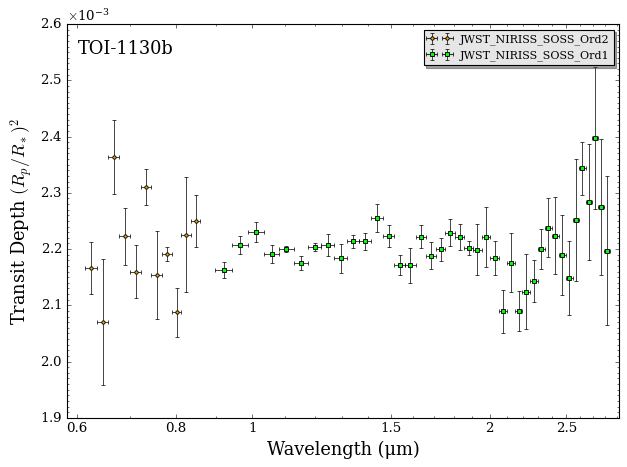

In [3]:
# Plot observed transmission spectrum - NIRISS only
wl_min = 0.60
wl_max = 2.9
res = 4000

wl = wl_grid_constant_R(wl_min, wl_max, res)

# Get datasets
data_dir = '/home/peng/POSEIDON/POSEIDON/reference_data/observations/TOI-1130b'
datasets = ['TOI-1130b_Order2.dat', 'TOI-1130b_Order1.dat']
instruments = ['JWST_NIRISS_SOSS_Ord2', 'JWST_NIRISS_SOSS_Ord1']

# Initial Retrieval Model - Water only
model_name = 'niriss_water_only'

bulk_species = ['H2', 'He']
param_species = ['H2O']

# Set offsets_applied to indicate 1, 2 or 3 offsets
model_onlywater = define_model(model_name, bulk_species, param_species, PT_profile = 'isotherm', cloud_model = 'cloud-free', offsets_applied = 'single_dataset')
data = load_data(data_dir, datasets, instruments, wl, 
                               offset_datasets = ['TOI-1130b_Order2.dat'])

fig_data = plot_data(data, planet_name)

In [4]:
# Set priors
prior_types, prior_ranges = {}, {}

prior_types['T'], prior_ranges['T'] = 'uniform', [500, 1000]
prior_types['R_p_ref'], prior_ranges['R_p_ref'] = 'uniform', [0.80*R_p, 1.20*R_p]
prior_types['log_X'], prior_ranges['log_X'] = 'uniform', [-12, -1]
prior_types['delta_rel_1'], prior_ranges['delta_rel_1'] = 'uniform', [-1000, 1000]    # Data offset is in ppm, this is Offset 1 for Order 2 relative to 1

priors = set_priors(planet, star, model_onlywater, data, prior_types, prior_ranges)

In [5]:
# Opacities
opacity_treatment = 'opacity_sampling'

T_fine = np.arange(500, 1000, 10)
log_P_fine = np.arange(-6.0, 2.0, 0.2)

opac = read_opacities(model_onlywater, wl, opacity_treatment, T_fine, log_P_fine)

Reading in cross sections in opacity sampling mode...
H2-H2 done
H2-He done
H2O done
Opacity pre-interpolation complete.


In [6]:
# Create atmosphere and run retrieval
P = np.logspace(np.log10(100), np.log10(1.0e-7), 100)
P_ref = 10.0

run_retrieval(planet, star, model_onlywater, opac, data, priors, wl, P, P_ref, R = res, spectrum_type = 'transmission', 
              sampling_algorithm = 'MultiNest', N_live = 400, verbose = False)

POSEIDON now running 'niriss_water_only'
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    4
 *****************************************************
POSEIDON retrieval finished in 0.15 hours
 ln(ev)=   404.75161045097030      +/-  0.17988524017526109     
 Total Likelihood Evaluations:        12606
 Sampling finished. Exiting MultiNest
Now generating 1000 sampled spectra and P-T profiles from the posterior distribution...
This process will take approximately 0.63 minutes
All done! Output files can be found in ./POSEIDON_output/TOI-1130b/retrievals/results/


Generating corner plot ...


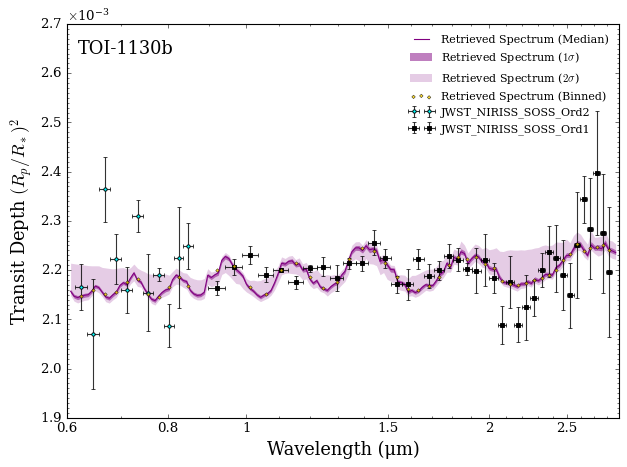

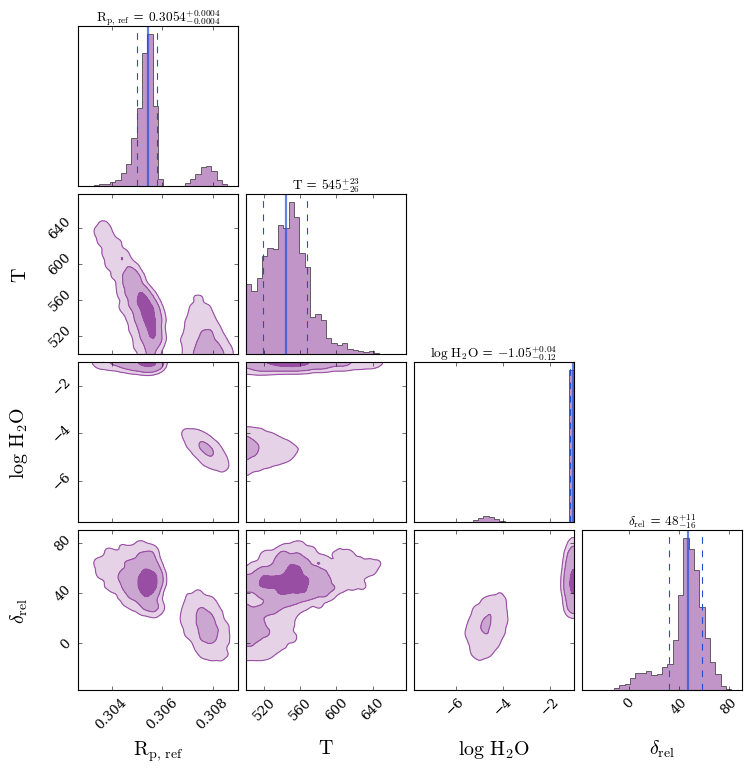

In [7]:
# Plot retrieval results
wl, spec_low2, spec_low1, spec_median, spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_name)

spectra_median = plot_collection(spec_median, wl, collection = [])
spectra_low1 = plot_collection(spec_low1, wl, collection = [])
spectra_low2 = plot_collection(spec_low2, wl, collection = [])
spectra_high1 = plot_collection(spec_high1, wl, collection = [])
spectra_high2 = plot_collection(spec_high2, wl, collection = [])

fig_spec = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1, spectra_high1, spectra_high2, planet_name, data, R_to_bin = 100,
                                  data_labels = ['JWST_NIRISS_SOSS_Ord2', 'JWST_NIRISS_SOSS_Ord1'], 
                                  data_colour_list = ['cyan', 'black'])

fig_corner = generate_cornerplot(planet, model_onlywater)

In [8]:
# Next, run retrievals for CO2, SO2 and CH4 as well to back up paper
model_name2 = 'niriss_add_co2_so2_ch4'

bulk_species = ['H2', 'He']
param_species2 = ['H2O', 'CO2', 'SO2', 'CH4']

model2 = define_model(model_name2, bulk_species, param_species2, PT_profile = 'isotherm', cloud_model = 'cloud-free', offsets_applied = 'single_dataset')

# Set priors
prior_types2, prior_ranges2 = {}, {}

prior_types2['T'], prior_ranges2['T'] = 'uniform', [500, 1000]
prior_types2['R_p_ref'], prior_ranges2['R_p_ref'] = 'uniform', [0.80*R_p, 1.20*R_p]
prior_types2['log_X'], prior_ranges2['log_X'] = 'uniform', [-12, -1]
prior_types2['delta_rel_1'], prior_ranges2['delta_rel_1'] = 'uniform', [-1000, 1000]   

priors2 = set_priors(planet, star, model2, data, prior_types2, prior_ranges2)

opacity_treatment = 'opacity_sampling'

T_fine = np.arange(500, 1000, 10)
log_P_fine = np.arange(-6.0, 2.0, 0.2)
P = np.logspace(np.log10(100), np.log10(1.0e-7), 100)
P_ref = 10.0

opac2 = read_opacities(model2, wl, opacity_treatment, T_fine, log_P_fine)

Reading in cross sections in opacity sampling mode...
H2-H2 done
H2-He done
H2-CH4 done
CO2-H2 done
CO2-CO2 done
CO2-CH4 done
H2O done
CO2 done
SO2 done
CH4 done
Opacity pre-interpolation complete.


In [9]:
# Run retrieval
run_retrieval(planet, star, model2, opac2, data, priors2, wl, P, P_ref, spectrum_type = 'transmission', 
              sampling_algorithm = 'MultiNest', N_live = 400, verbose = False)

POSEIDON now running 'niriss_add_co2_so2_ch4'
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    7
 *****************************************************
POSEIDON retrieval finished in 0.21 hours
 ln(ev)=   416.88011670754378      +/-  0.17686855446785127     
 Total Likelihood Evaluations:        16802
 Sampling finished. Exiting MultiNest
Now generating 1000 sampled spectra and P-T profiles from the posterior distribution...
This process will take approximately 0.71 minutes
All done! Output files can be found in ./POSEIDON_output/TOI-1130b/retrievals/results/


Generating corner plot ...


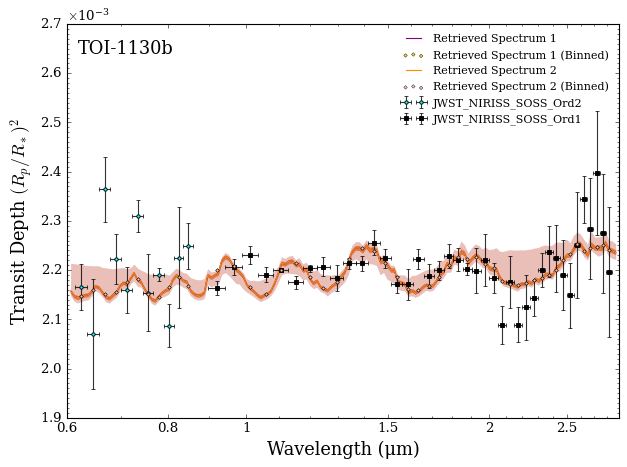

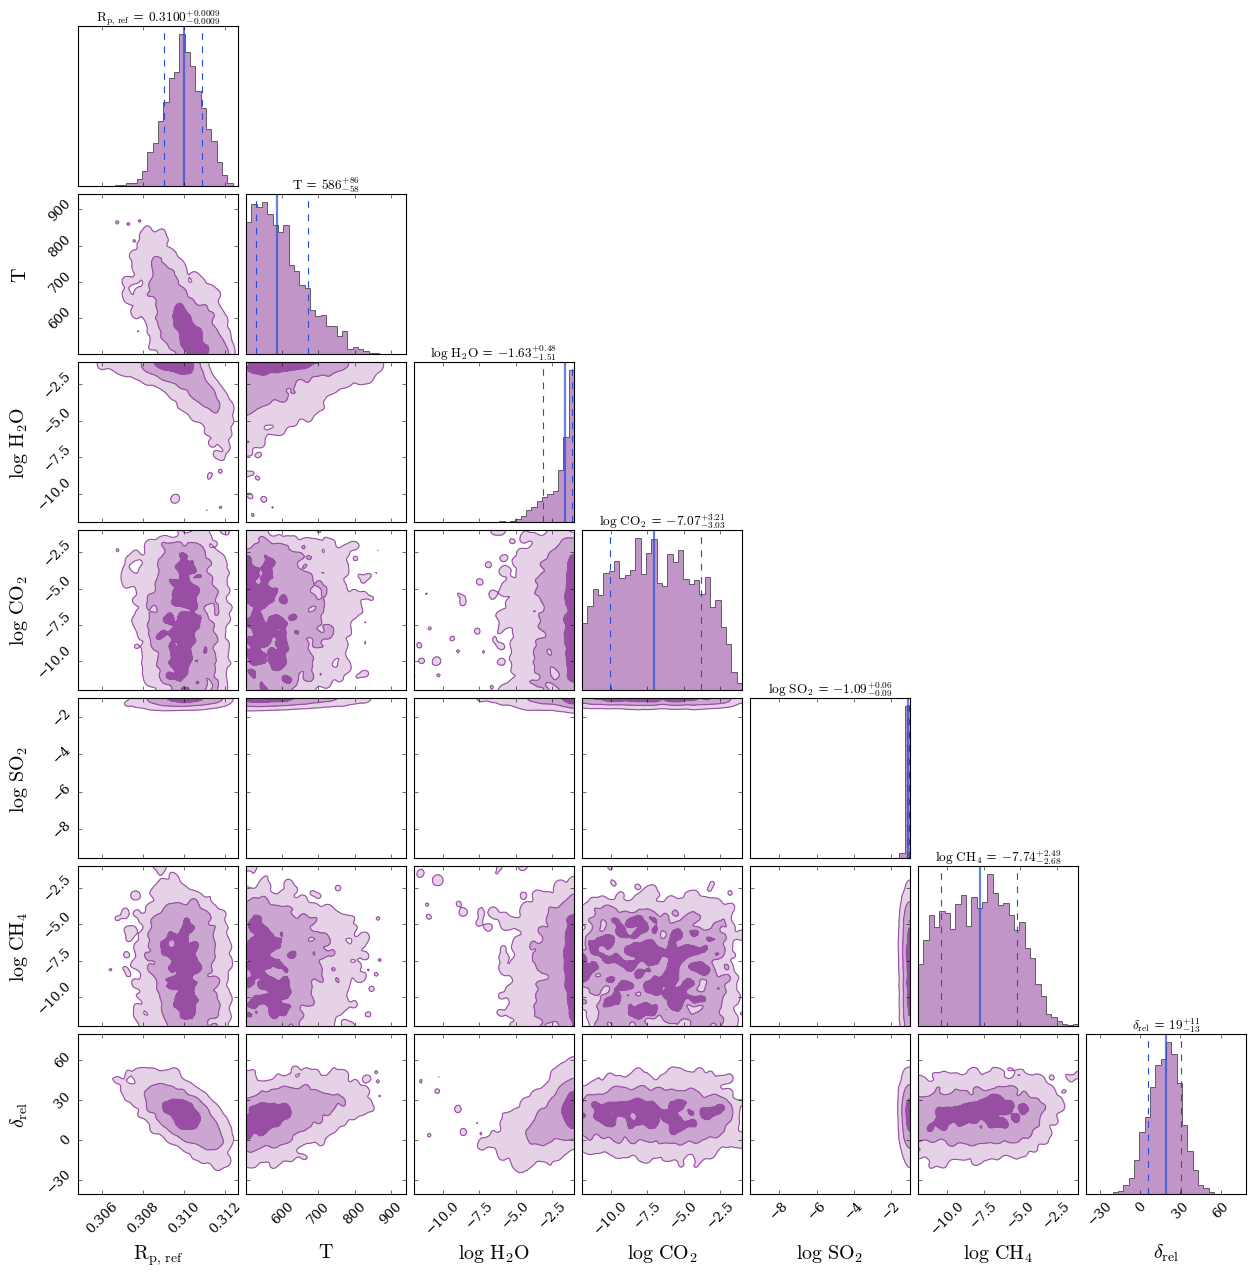

In [10]:
# Plot results
wl, spec_low2, spec_low1, spec_median, spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_name)

spectra_median = plot_collection(spec_median, wl, collection = spectra_median)
spectra_low1 = plot_collection(spec_low1, wl, collection = spectra_low1)
spectra_low2 = plot_collection(spec_low2, wl, collection = spectra_low2)
spectra_high1 = plot_collection(spec_high1, wl, collection = spectra_high1)
spectra_high2 = plot_collection(spec_high2, wl, collection = spectra_high2)

fig_spec = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1, spectra_high1, spectra_high2, planet_name, data, R_to_bin = 100,
                                  data_labels = ['JWST_NIRISS_SOSS_Ord2', 'JWST_NIRISS_SOSS_Ord1'], 
                                  data_colour_list = ['cyan', 'black'])

fig_corner = generate_cornerplot(planet, model2)

In [14]:
Bayesian_model_comparison(planet_name, model_onlywater, model2)

Bayesian evidences:

Model unbin_niriss_water_only: ln Z = 406.94 +/- 0.18
Model unbin_niriss_add_co2_so2_ch4: ln Z = 417.25 +/- 0.18

Bayes factor:

B = 3.34e-05
ln B = -10.31

No detection of the reference model, model unbin_niriss_add_co2_so2_ch4 is preferred.



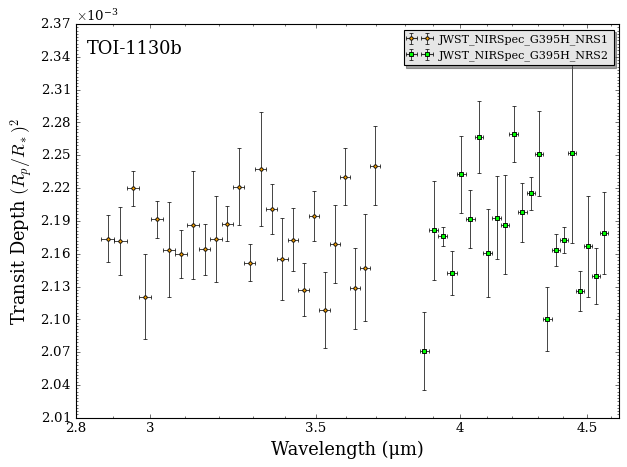

In [3]:
# Plot observed transmission spectrum - NIRSpec only
wl_min = 2.7
wl_max = 5.2
res = 4000

wl = wl_grid_constant_R(wl_min, wl_max, res)

# Get datasets
data_dir = '/home/peng/POSEIDON/POSEIDON/reference_data/observations/TOI-1130b'
datasets = ['TOI-1130b_NRS1.dat', 'TOI-1130b_NRS2_cut.dat']
instruments = ['JWST_NIRSpec_G395H_NRS1', 'JWST_NIRSpec_G395H_NRS2']

# Initial Retrieval Model - Water only
model_name = 'nirspec_water_only'

bulk_species = ['H2', 'He']
param_species = ['H2O']

model_onlywater = define_model(model_name, bulk_species, param_species, PT_profile = 'isotherm', cloud_model = 'cloud-free', offsets_applied = 'single_dataset')
data = load_data(data_dir, datasets, instruments, wl, 
                               offset_datasets = ['TOI-1130b_NRS2_cut.dat'])

fig_data = plot_data(data, planet_name)

In [4]:
# Set priors
prior_types, prior_ranges = {}, {}

prior_types['T'], prior_ranges['T'] = 'uniform', [500, 1000]
prior_types['R_p_ref'], prior_ranges['R_p_ref'] = 'uniform', [0.80*R_p, 1.20*R_p]
prior_types['log_X'], prior_ranges['log_X'] = 'uniform', [-12, -1]
prior_types['delta_rel_1'], prior_ranges['delta_rel_1'] = 'uniform', [-1000, 1000]    # Data offset is in ppm, this is Offset 1 for Order 2 relative to 1

priors = set_priors(planet, star, model_onlywater, data, prior_types, prior_ranges)

In [5]:
# Opacities
opacity_treatment = 'opacity_sampling'

T_fine = np.arange(500, 1000, 10)
log_P_fine = np.arange(-6.0, 2.0, 0.2)

opac = read_opacities(model_onlywater, wl, opacity_treatment, T_fine, log_P_fine)

Reading in cross sections in opacity sampling mode...
H2-H2 done
H2-He done
H2O done
Opacity pre-interpolation complete.


In [6]:
# Create atmosphere and run retrieval
P = np.logspace(np.log10(100), np.log10(1.0e-7), 100)
P_ref = 10.0

run_retrieval(planet, star, model_onlywater, opac, data, priors, wl, P, P_ref, R = res, spectrum_type = 'transmission', 
              sampling_algorithm = 'MultiNest', N_live = 400, verbose = False)

POSEIDON now running 'nirspec_water_only'
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    4
 *****************************************************
POSEIDON retrieval finished in 0.043 hours
 ln(ev)=   387.37969940768266      +/-  0.13569476793694299     
 Total Likelihood Evaluations:         7476
 Sampling finished. Exiting MultiNest
Now generating 1000 sampled spectra and P-T profiles from the posterior distribution...
This process will take approximately 0.32 minutes
All done! Output files can be found in ./POSEIDON_output/TOI-1130b/retrievals/results/


Generating corner plot ...


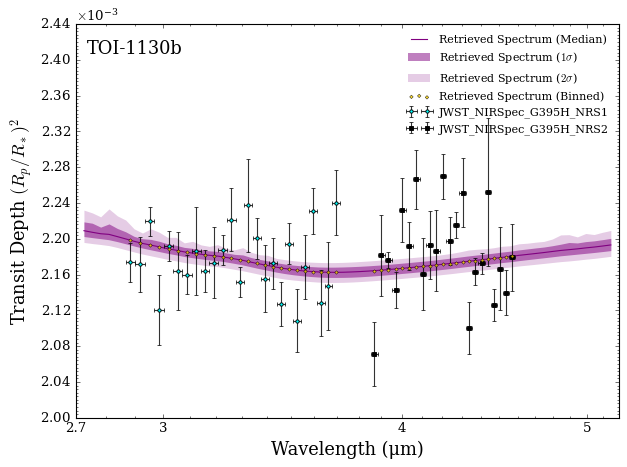

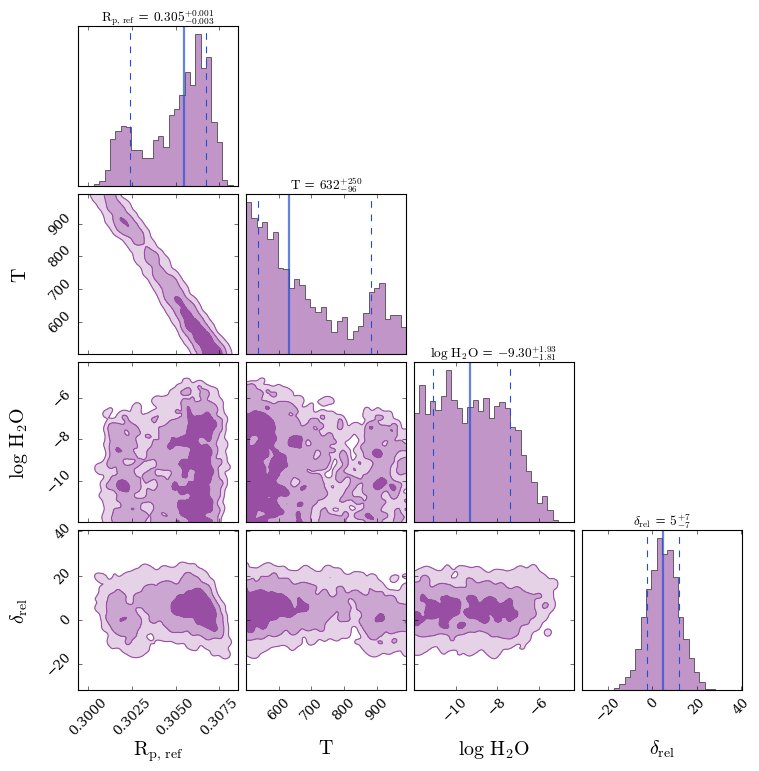

In [7]:
# Plot retrieval results
wl, spec_low2, spec_low1, spec_median, spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_name)

spectra_median = plot_collection(spec_median, wl, collection = [])
spectra_low1 = plot_collection(spec_low1, wl, collection = [])
spectra_low2 = plot_collection(spec_low2, wl, collection = [])
spectra_high1 = plot_collection(spec_high1, wl, collection = [])
spectra_high2 = plot_collection(spec_high2, wl, collection = [])

fig_spec = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1, spectra_high1, spectra_high2, planet_name, data, R_to_bin = 100,
                                  data_labels = ['JWST_NIRSpec_G395H_NRS1', 'JWST_NIRSpec_G395H_NRS2'], 
                                  data_colour_list = ['cyan', 'black'])

fig_corner = generate_cornerplot(planet, model_onlywater)

In [8]:
# Next, run retrievals for CO2, SO2 and CH4 as well to back up paper
model_name2 = 'nirspec_add_co2_so2_ch4'

bulk_species = ['H2', 'He']
param_species2 = ['H2O', 'CO2', 'SO2', 'CH4']

model2 = define_model(model_name2, bulk_species, param_species2, PT_profile = 'isotherm', cloud_model = 'cloud-free', offsets_applied = 'single_dataset')

# Set priors
prior_types2, prior_ranges2 = {}, {}

prior_types2['T'], prior_ranges2['T'] = 'uniform', [500, 1000]
prior_types2['R_p_ref'], prior_ranges2['R_p_ref'] = 'uniform', [0.80*R_p, 1.20*R_p]
prior_types2['log_X'], prior_ranges2['log_X'] = 'uniform', [-12, -1]
prior_types2['delta_rel_1'], prior_ranges2['delta_rel_1'] = 'uniform', [-1000, 1000]   

priors2 = set_priors(planet, star, model2, data, prior_types2, prior_ranges2)

opacity_treatment = 'opacity_sampling'

T_fine = np.arange(500, 1000, 10)
log_P_fine = np.arange(-6.0, 2.0, 0.2)
P = np.logspace(np.log10(100), np.log10(1.0e-7), 100)
P_ref = 10.0

opac2 = read_opacities(model2, wl, opacity_treatment, T_fine, log_P_fine)

Reading in cross sections in opacity sampling mode...
H2-H2 done
H2-He done
H2-CH4 done
CO2-H2 done
CO2-CO2 done
CO2-CH4 done
H2O done
CO2 done
SO2 done
CH4 done
Opacity pre-interpolation complete.


In [9]:
# Run retrieval
run_retrieval(planet, star, model2, opac2, data, priors2, wl, P, P_ref, spectrum_type = 'transmission', 
              sampling_algorithm = 'MultiNest', N_live = 400, verbose = False)

POSEIDON now running 'nirspec_add_co2_so2_ch4'
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    7
 *****************************************************
POSEIDON retrieval finished in 0.12 hours ln(ev)=   386.84971371683065      +/-  0.15131787116567630     
 Total Likelihood Evaluations:        19778
 Sampling finished. Exiting MultiNest

Now generating 1000 sampled spectra and P-T profiles from the posterior distribution...
This process will take approximately 0.34 minutes
All done! Output files can be found in ./POSEIDON_output/TOI-1130b/retrievals/results/


Generating corner plot ...


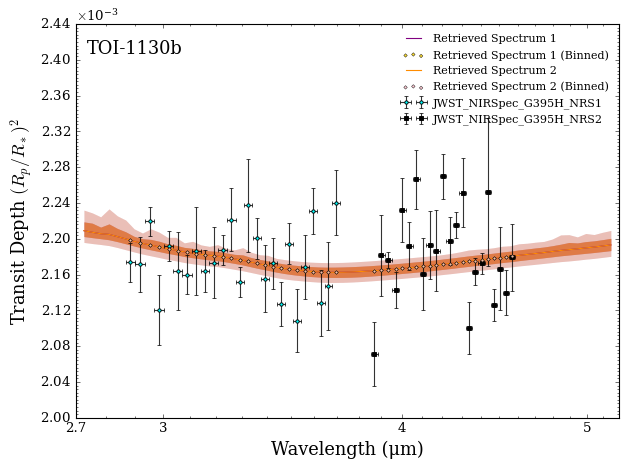

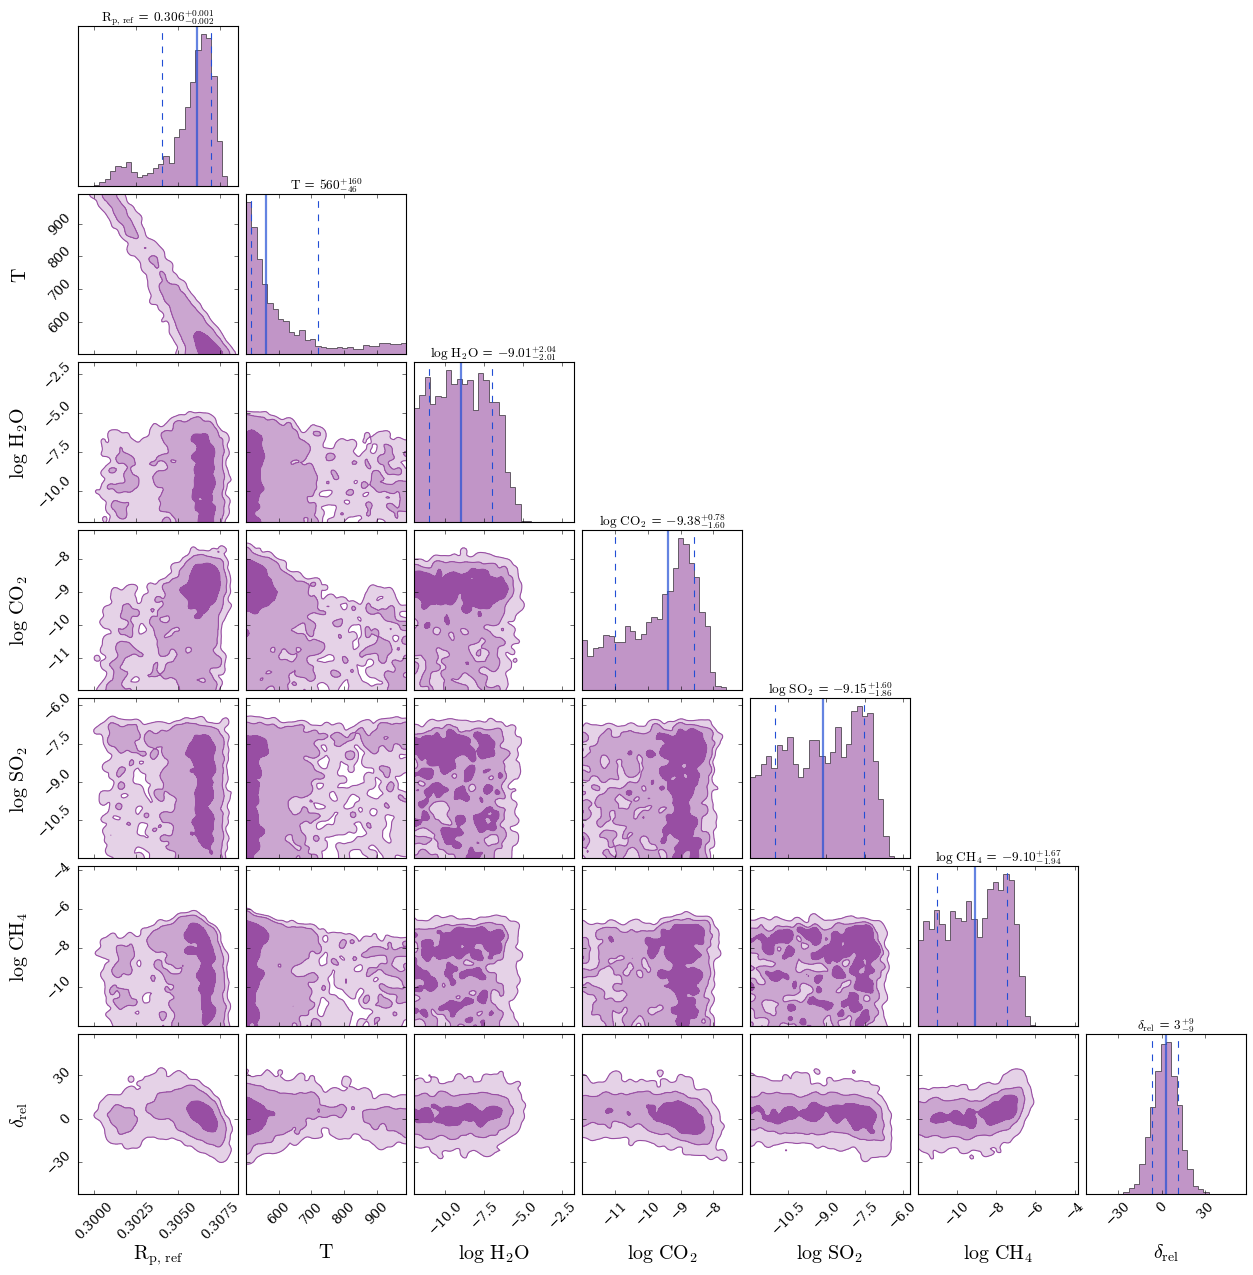

In [10]:
# Plot retrieval results
wl, spec_low2, spec_low1, spec_median, spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_name)

spectra_median = plot_collection(spec_median, wl, collection = spectra_median)
spectra_low1 = plot_collection(spec_low1, wl, collection = spectra_low1)
spectra_low2 = plot_collection(spec_low2, wl, collection = spectra_low2)
spectra_high1 = plot_collection(spec_high1, wl, collection = spectra_high1)
spectra_high2 = plot_collection(spec_high2, wl, collection = spectra_high2)

fig_spec = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1, spectra_high1, spectra_high2, planet_name, data, R_to_bin = 100,
                                  data_labels = ['JWST_NIRSpec_G395H_NRS1', 'JWST_NIRSpec_G395H_NRS2'], 
                                  data_colour_list = ['cyan', 'black'])

fig_corner = generate_cornerplot(planet, model2)